# Strategy 02 — RSI Mean Reversion with ATR Stops

End-to-end backtest of the RSI mean-reversion strategy documented in
[`DocumentationVault/strategies/02_RSI_Mean_Reversion.md`](../DocumentationVault/strategies/02_RSI_Mean_Reversion.md).

The notebook follows the same six-section template as the baseline so the two
notebooks can be read side by side:

1. Load data
2. Multi-timeframe preparation (15 min / 1 h / 4 h — per the strategy doc)
3. Strategy definition + baseline backtest with default parameters
4. Walk-Forward Optimization (5 folds, 75 % IS / 25 % OOS) and full-history
   backtest with WFO-picked parameters
5. Robustness — Monte Carlo, block bootstrap, sub-period, parameter sensitivity
6. Takeaways

**Scope deviations from the doc.** The strategy doc lists Crypto (BTCUSDT, ETHUSDT)
as a target market, but no crypto data is checked into this repo, so the notebook
runs on Forex only. The `use_midline_exit` toggle is left **off** — exiting on
RSI's 50 cross is described in the doc but cannot be expressed cleanly through
the existing `Backtester`'s SL / TP / signal-reversal contract; adding a
custom-exit hook is a separate change.

Section 7 extensions (session filter, position sizing modes, correlation-aware
weighting) are out of scope for this notebook and will be added as a follow-up.

In [1]:
# Make the `source/` package importable from this notebook's location.
import gc
import sys
from pathlib import Path
from collections import Counter

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from source import (
    discover_datasets, build_lazy_grid, LazyDataset,
    RSIMeanReversionStrategy, RSIMeanReversionParams,
    Backtester, compute_metrics,
    plot_backtest_dashboard, plot_wfo_dashboard, plot_robustness_dashboard,
    walk_forward, WFOResult,
    monte_carlo_trades, monte_carlo_summary,
    block_bootstrap_trades, subperiod_analysis, parameter_sensitivity,
    run_backtest_grid, run_backtests_with_params, run_wfo_grid,
    reshape_grid_results, cpu_count,
)

N_JOBS = "auto"
print(f"Parallelism budget: n_jobs={N_JOBS!r} (cpu_count={cpu_count()})")


Parallelism budget: n_jobs='auto' (cpu_count=15)


## 1. Load the data

`load_all` discovers every CSV in `data/` and its subdirectories. The strategy
doc targets Forex and Crypto — only Forex is loaded here because no Crypto data
is checked into the repo.

In [2]:
# Metadata-only scan — no CSV is read until each LazyDataset's .load() fires.
metas = discover_datasets(REPO_ROOT / "data")
print(f"Discovered {len(metas)} dataset(s):")
for (asset, tf), meta in metas.items():
    group_tag = f"[{meta.group}]" if meta.group else "[root]"
    print(f"  {group_tag:8s} {asset:10s} {tf:4s}  {meta.start.date()} -> {meta.end.date()}")

forex_assets = sorted({a for (a, _), m in metas.items() if m.group == "forex"})
target_groups = {"forex", "crypto"}
present_groups = {m.group for m in metas.values()}
missing = sorted(target_groups - present_groups)
if missing:
    print(f"\n[note] Strategy targets {sorted(target_groups)} but no data is present for: {missing}. Continuing with: {sorted(target_groups & present_groups)}.")
if not forex_assets:
    raise RuntimeError("No forex data found — the RSI notebook needs at least one target group with local data.")


Discovered 5 dataset(s):
  [b3]     WDO        M1    2021-04-30 -> 2026-04-29
  [b3]     WIN        M1    2021-04-30 -> 2026-04-29
  [forex]  EURCAD     M1    2016-04-11 -> 2026-04-21
  [forex]  EURUSD     M1    2016-04-11 -> 2026-04-21
  [forex]  GBPCHF     M1    2016-04-11 -> 2026-04-21

[note] Strategy targets ['crypto', 'forex'] but no data is present for: ['crypto']. Continuing with: ['forex'].


## 2. Multi-timeframe preparation

The doc lists **15 min, 1 h, 4 h** as the target timeframes for Forex. RSI
mean-reversion is most commonly studied at intra-day to multi-hour horizons —
daily bars are too sparse for the threshold-crossing entry signal.

In [3]:
GROUP_TIMEFRAMES = {
    "forex": ["15min", "1h", "4h"],
}

# Lazy grid: nothing is loaded until run_backtest_grid / run_wfo_grid hands a
# spec to a worker.  RAM stays flat regardless of (assets × timeframes) count.
group_tfs = build_lazy_grid(REPO_ROOT / "data", group_timeframes=GROUP_TIMEFRAMES)
group_tfs = {g: tfs for g, tfs in group_tfs.items() if g in GROUP_TIMEFRAMES}

for group, tfs in group_tfs.items():
    print(f"\n{group.upper()}:")
    for tf, assets in tfs.items():
        print(f"  {tf:6s}  assets={list(assets)}")



FOREX:
  15min   assets=['EURCAD', 'EURUSD', 'GBPCHF']
  1h      assets=['EURCAD', 'EURUSD', 'GBPCHF']
  4h      assets=['EURCAD', 'EURUSD', 'GBPCHF']


## 3. Strategy definition — RSI mean reversion with ATR stops

**Entry**
- Long when RSI crosses **up through** `rsi_lower` (default 30) — oversold
  rejection.
- Short when RSI crosses **down through** `rsi_upper` (default 70) — overbought
  rejection.

**Exit**
- Hard stop at `entry ∓ sl_atr_mult × ATR_entry`.
- Hard target at `entry ± tp_atr_mult × ATR_entry`.
- An opposite RSI threshold crossover reverses the position (handled by the
  `Backtester`'s signal-reversal logic).

**Filters**
- ADX regime filter is **off** by default. When enabled, entries are suppressed
  while `ADX > adx_max` (so the strategy avoids fighting strong trends).
- The doc's `use_midline_exit` toggle (exit on RSI = 50 cross) is left off — see
  the title cell for why.

Indicators implemented per the doc: Wilder's RSI (`α = 1 / rsi_period`), simple
rolling-mean ATR, and Wilder ADX (only computed when the filter is on).

In [4]:
baseline_params = RSIMeanReversionParams(
    rsi_period=14,
    rsi_lower=30.0,
    rsi_upper=70.0,
    atr_period=14,
    sl_atr_mult=1.5,
    tp_atr_mult=2.0,
)

SUMMARY_METRICS = [
    "num_trades", "total_pnl", "win_rate", "profit_factor",
    "expectancy", "max_drawdown", "sharpe_daily", "sharpe_per_trade", "p_value",
]


class _PortfolioResult:
    """Lightweight result container for a combined multi-asset portfolio."""
    def __init__(self, trades, equity):
        self.trades = trades
        self.equity = equity


def build_portfolio(per_asset_results):
    """Merge per-asset BacktestResult objects into a single portfolio."""
    frames = []
    for asset, result in per_asset_results.items():
        if not result.trades.empty:
            t = result.trades.copy()
            t.insert(0, "asset", asset)
            frames.append(t)
    if not frames:
        return _PortfolioResult(pd.DataFrame(), pd.Series(dtype=float))
    combined = (
        pd.concat(frames, ignore_index=True)
        .sort_values("exit_time")
        .reset_index(drop=True)
    )
    equity = pd.Series(
        combined["pnl_points"].cumsum().values,
        index=pd.to_datetime(combined["exit_time"].values),
        name="equity_points",
    )
    return _PortfolioResult(combined, equity)


def metrics_comparison(portfolio_dict, keys=None):
    keys = keys or SUMMARY_METRICS
    rows = {}
    for tf, portfolio in portfolio_dict.items():
        m = compute_metrics(portfolio)
        rows[tf] = {k: m[k] for k in keys if k in m}
    return pd.DataFrame(rows)


In [5]:
# Baseline backtest across all (group, tf, asset) cells in parallel.  Each
# worker loads + resamples + backtests + returns a BacktestResult; the parent
# never holds an OHLC frame.
flat_results = run_backtest_grid(
    group_tfs,
    baseline_params,
    strategy_cls=RSIMeanReversionStrategy,
    n_jobs=N_JOBS,
)
baseline_per_asset = reshape_grid_results(flat_results)
baseline_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in baseline_per_asset.items()
}

for group in baseline_portfolio:
    for tf, portfolio in baseline_portfolio[group].items():
        n = len(portfolio.trades) if not portfolio.trades.empty else 0
        print(f"{group:5s}  {tf:6s}  {n:>6,} trades")


  backtest [9/9]


forex  15min   16,545 trades
forex  1h       4,691 trades
forex  4h       1,247 trades


### 3.1 Forex — baseline across timeframes

Portfolio metrics for each timeframe, plus a per-asset breakdown and equity-curve dashboards.

In [6]:
print("Portfolio metrics — Forex (all assets combined, per timeframe):")
display(metrics_comparison(baseline_portfolio["forex"]))

print("\nPer-asset breakdown by timeframe:")
for tf, asset_results in baseline_per_asset["forex"].items():
    print(f"\n  {tf}:")
    detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
    display(
        pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ]
    )

Portfolio metrics — Forex (all assets combined, per timeframe):


,15min,1h,4h
num_trades,16545.000000,4691.000000,1247.000000
total_pnl,-0.340475,-0.439733,-0.139965
win_rate,0.425264,0.415690,0.421010
profit_factor,0.976460,0.943357,0.965835
expectancy,-0.000021,-0.000094,-0.000112
max_drawdown,-0.532169,-0.474366,-0.486267
sharpe_daily,-0.342453,-0.421560,-0.133081
sharpe_per_trade,-1.314923,-1.771265,-0.553346
p_value,0.188536,0.076517,0.580027



Per-asset breakdown by timeframe:

  15min:


,EURCAD,EURUSD,GBPCHF
num_trades,5438.000000,5816.000000,5291.000000
total_pnl,0.055248,-0.116584,-0.279139
sharpe_daily,0.088864,-0.260766,-0.458290
profit_factor,1.010606,0.972190,0.944854
max_drawdown,-0.149904,-0.205609,-0.358593



  1h:


,EURCAD,EURUSD,GBPCHF
num_trades,1530.000000,1676.000000,1485.000000
total_pnl,-0.104272,-0.108099,-0.227361
sharpe_daily,-0.169816,-0.239394,-0.374513
profit_factor,0.962324,0.952719,0.916080
max_drawdown,-0.214199,-0.155702,-0.317840



  4h:


,EURCAD,EURUSD,GBPCHF
num_trades,389.000000,435.000000,423.000000
total_pnl,0.030143,0.007150,-0.177258
sharpe_daily,0.052194,0.015819,-0.297170
profit_factor,1.022065,1.006246,0.888226
max_drawdown,-0.152283,-0.103045,-0.393365


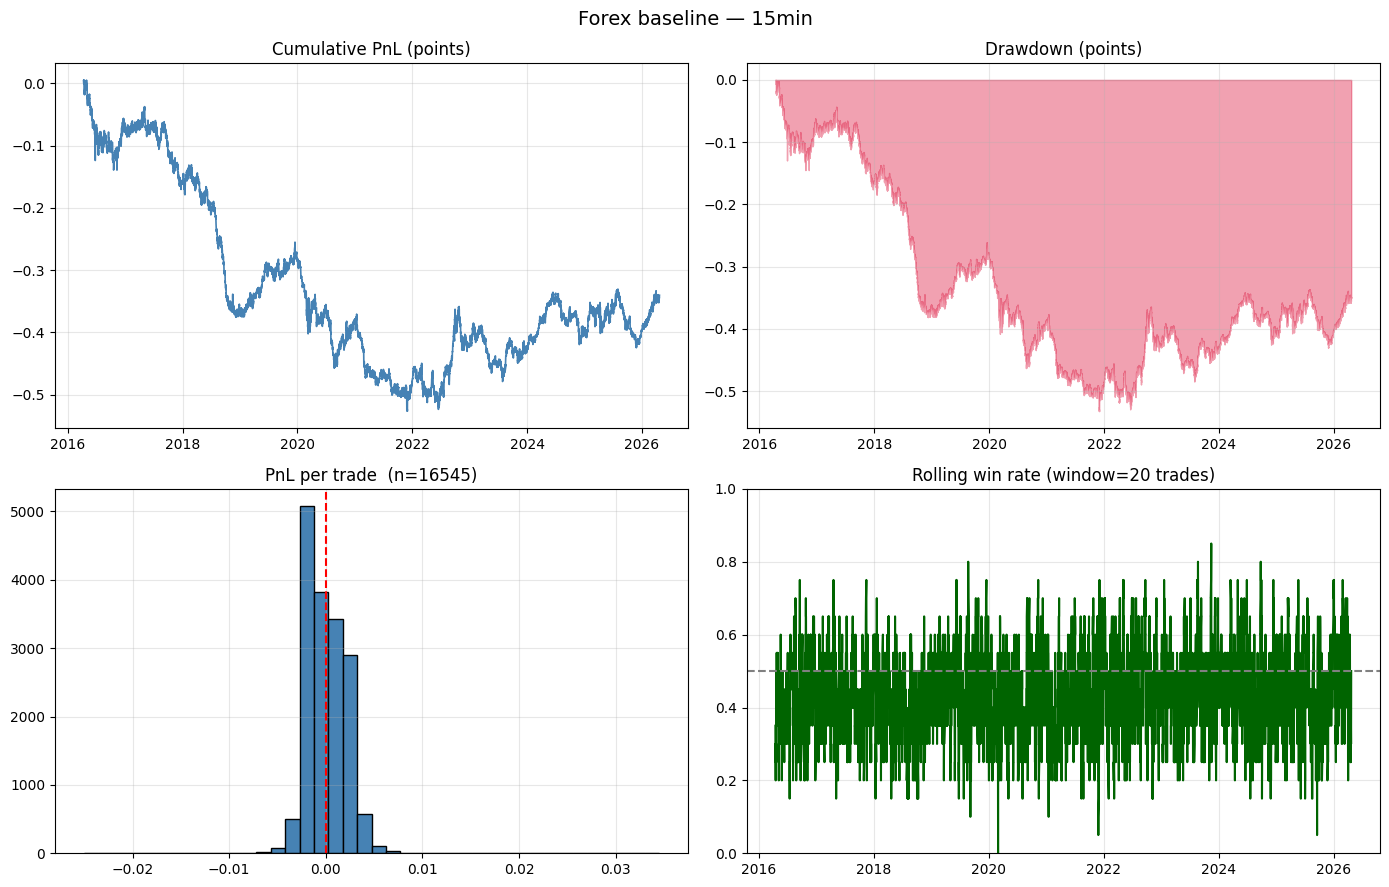

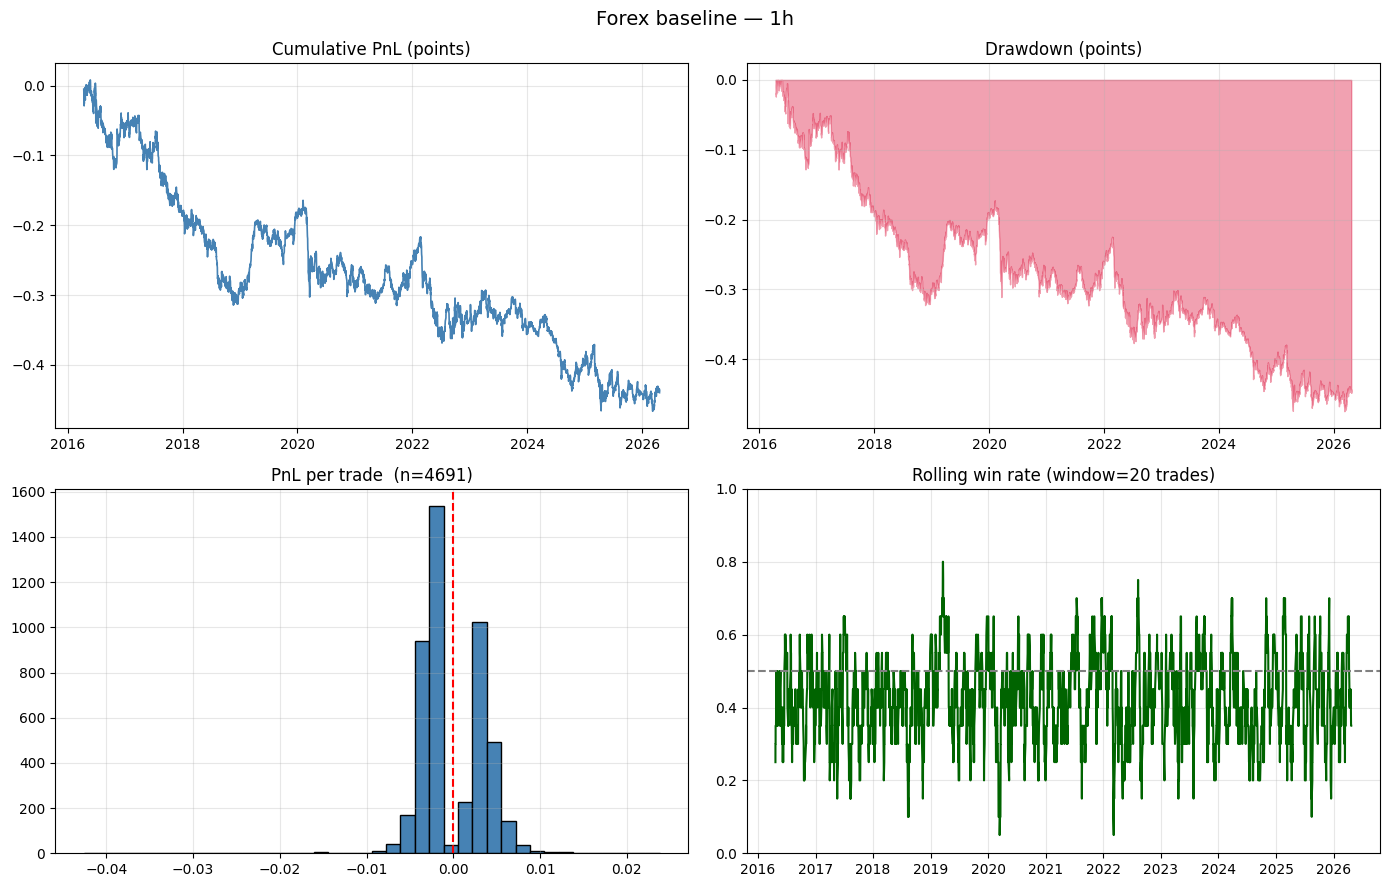

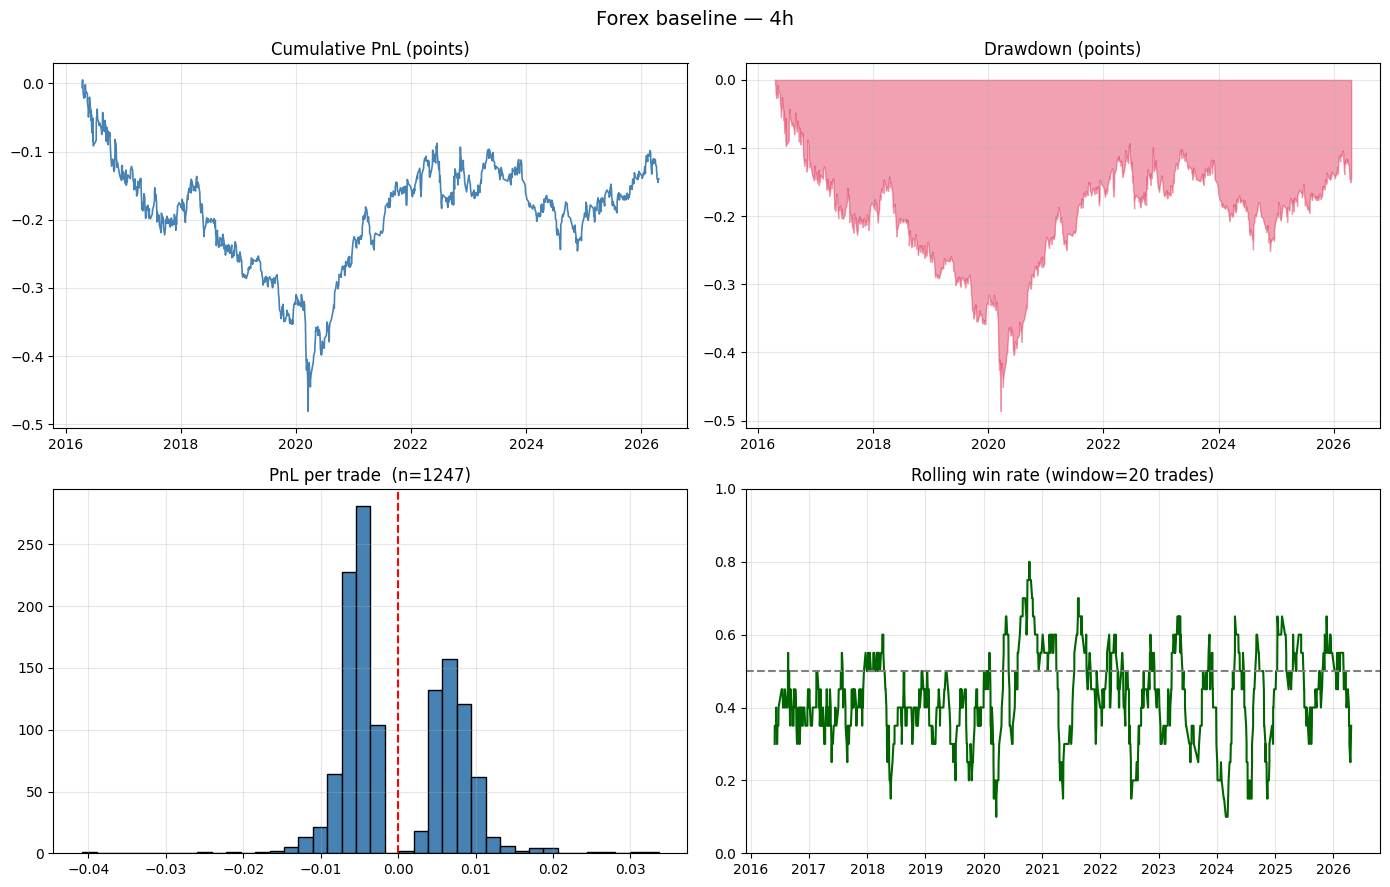

In [7]:
for tf, portfolio in baseline_portfolio["forex"].items():
    if portfolio.trades.empty:
        print(f"  {tf}: no trades — skipping")
        continue
    fig = plot_backtest_dashboard(portfolio, title=f"Forex baseline — {tf}")
    plt.show()

## 4. Walk-Forward Optimization

Each (group, timeframe, asset) runs an independent WFO with `n_splits=5` and
`oos_ratio=0.25` — the same defaults as the SMA baseline. In-sample objective:
maximize daily Sharpe.

WFO grid (taken directly from the strategy doc's "Parameters" table):

| Parameter | Values |
|-----------|--------|
| `rsi_period` | 7, 10, 14, 20 |
| `rsi_lower` | 25, 30, 35 |
| `rsi_upper` | 65, 70, 75 |
| `sl_atr_mult` | 1.0, 1.5, 2.0, 2.5 |
| `tp_atr_mult` | 1.5, 2.0, 3.0 |

Total combinations: 4 × 3 × 3 × 4 × 3 = **432**. The `rsi_lower < 50 < rsi_upper`
constraint is automatically satisfied by every cell of the grid.

In [8]:
param_grid = {
    "rsi_period":  [7, 10, 14, 20],
    "rsi_lower":   [25.0, 30.0, 35.0],
    "rsi_upper":   [65.0, 70.0, 75.0],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5],
    "tp_atr_mult": [1.5, 2.0, 3.0],
}


def build_combined_wfo(wfo_per_asset_tf):
    """Merge per-asset WFOResults into a single combined WFOResult."""
    _oos_frames = []
    for asset, wfo in wfo_per_asset_tf.items():
        if not wfo.oos_trades.empty:
            t = wfo.oos_trades.copy()
            t.insert(0, "asset", asset)
            _oos_frames.append(t)
    if not _oos_frames:
        return WFOResult(
            windows=pd.DataFrame(),
            oos_equity=pd.Series(dtype=float),
            oos_trades=pd.DataFrame(),
        )
    combined_oos = (
        pd.concat(_oos_frames, ignore_index=True)
        .sort_values("exit_time")
        .reset_index(drop=True)
    )
    oos_equity = pd.Series(
        combined_oos["pnl_points"].cumsum().values,
        index=pd.to_datetime(combined_oos["exit_time"].values),
        name="equity_points",
    )
    sample_wfo = next(iter(wfo_per_asset_tf.values()))
    fold_rows = []
    if "fold" in combined_oos.columns and not sample_wfo.windows.empty:
        fold_nums = sorted(combined_oos["fold"].unique())
        avg_deg = {}
        for fn in fold_nums:
            degs = []
            for wfo in wfo_per_asset_tf.values():
                if wfo.windows.empty or "degradation_ratio" not in wfo.windows.columns:
                    continue
                fw = wfo.windows[wfo.windows["fold"] == fn]
                if not fw.empty and pd.notna(fw.iloc[0]["degradation_ratio"]):
                    degs.append(float(fw.iloc[0]["degradation_ratio"]))
            avg_deg[fn] = float(np.nanmean(degs)) if degs else np.nan
        for fold_num in fold_nums:
            _ft = combined_oos[combined_oos["fold"] == fold_num].sort_values("exit_time")
            _feq = pd.Series(
                _ft["pnl_points"].cumsum().values,
                index=pd.to_datetime(_ft["exit_time"].values),
            )
            _fm = compute_metrics(_PortfolioResult(_ft, _feq))
            _bnd = sample_wfo.windows[sample_wfo.windows["fold"] == fold_num].iloc[0]
            param_cols = {k: v for k, v in _bnd.items() if str(k).startswith("param_")}
            fold_rows.append({
                "fold": fold_num,
                "is_start": _bnd["is_start"],  "is_end": _bnd["is_end"],
                "oos_start": _bnd["oos_start"], "oos_end": _bnd["oos_end"],
                "oos_pnl": _fm["total_pnl"],    "oos_sharpe": _fm["sharpe_daily"],
                "oos_profit_factor": _fm["profit_factor"],
                "oos_win_rate": _fm["win_rate"], "oos_trades": _fm["num_trades"],
                "degradation_ratio": avg_deg.get(fold_num, np.nan),
                **param_cols,
            })
    return WFOResult(
        windows=pd.DataFrame(fold_rows),
        oos_equity=oos_equity,
        oos_trades=combined_oos,
    )


# Outer parallelism over (group, tf, asset) cells.  Inner fold-level
# parallelism is left at 1 because the outer grid (3 TFs × 3 assets = 9 cells)
# is already > #cores.
flat_wfo = run_wfo_grid(
    group_tfs,
    param_grid=param_grid,
    n_splits=5,
    oos_ratio=0.25,
    strategy_cls=RSIMeanReversionStrategy,
    params_cls=RSIMeanReversionParams,
    n_jobs=N_JOBS,
    inner_n_jobs=1,
)
wfo_per_asset = reshape_grid_results(flat_wfo)
wfo_combined = {
    g: {tf: build_combined_wfo(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in wfo_per_asset.items()
}

for group in wfo_combined:
    for tf, wfo in wfo_combined[group].items():
        print(f"{group:5s}  {tf:6s}  {len(wfo.oos_trades):>6,} OOS trades")


  WFO [9/9]


forex  15min    3,801 OOS trades
forex  1h       1,183 OOS trades
forex  4h         308 OOS trades


### 4.1 Forex — WFO out-of-sample results

OOS portfolio metrics — Forex (per timeframe):


,15min,1h,4h
num_trades,3801.000000,1183.000000,308.000000
total_pnl,0.141257,-0.092418,0.021461
win_rate,0.546435,0.467456,0.483766
profit_factor,1.047382,0.950479,1.023661
expectancy,0.000037,-0.000078,0.000070
max_drawdown,-0.119539,-0.194089,-0.145733
sharpe_daily,0.327444,-0.207049,0.052847
sharpe_per_trade,1.179190,-0.701917,0.171802
p_value,0.238323,0.482731,0.863593


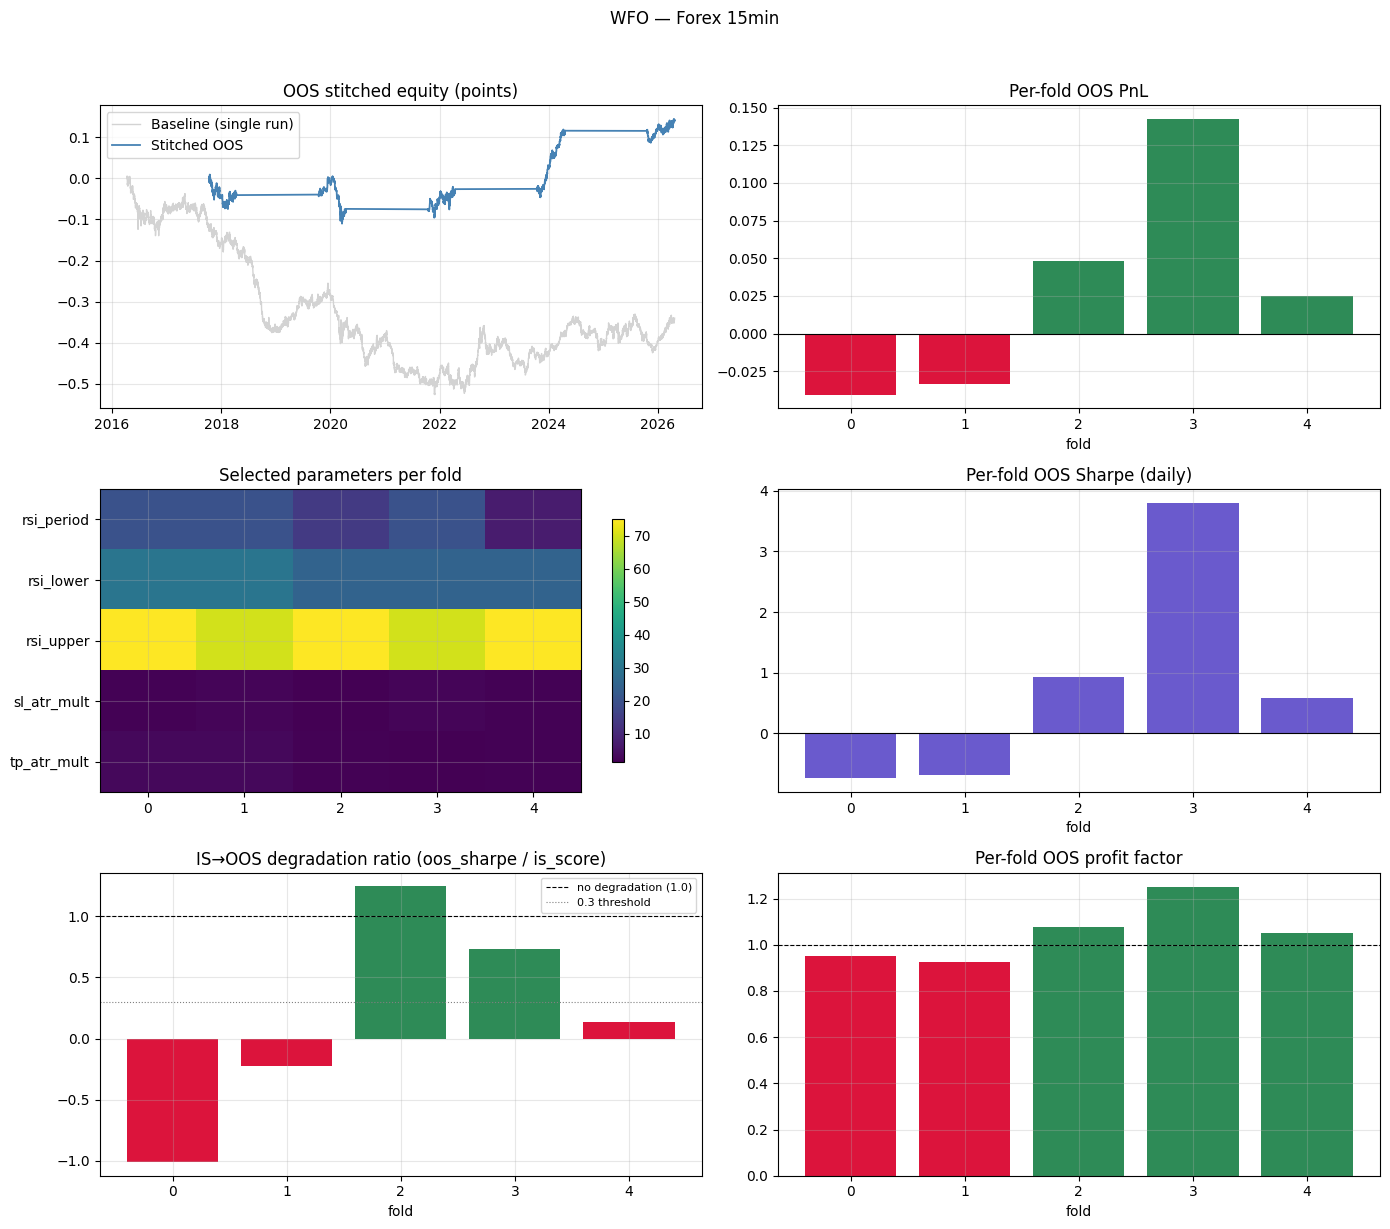

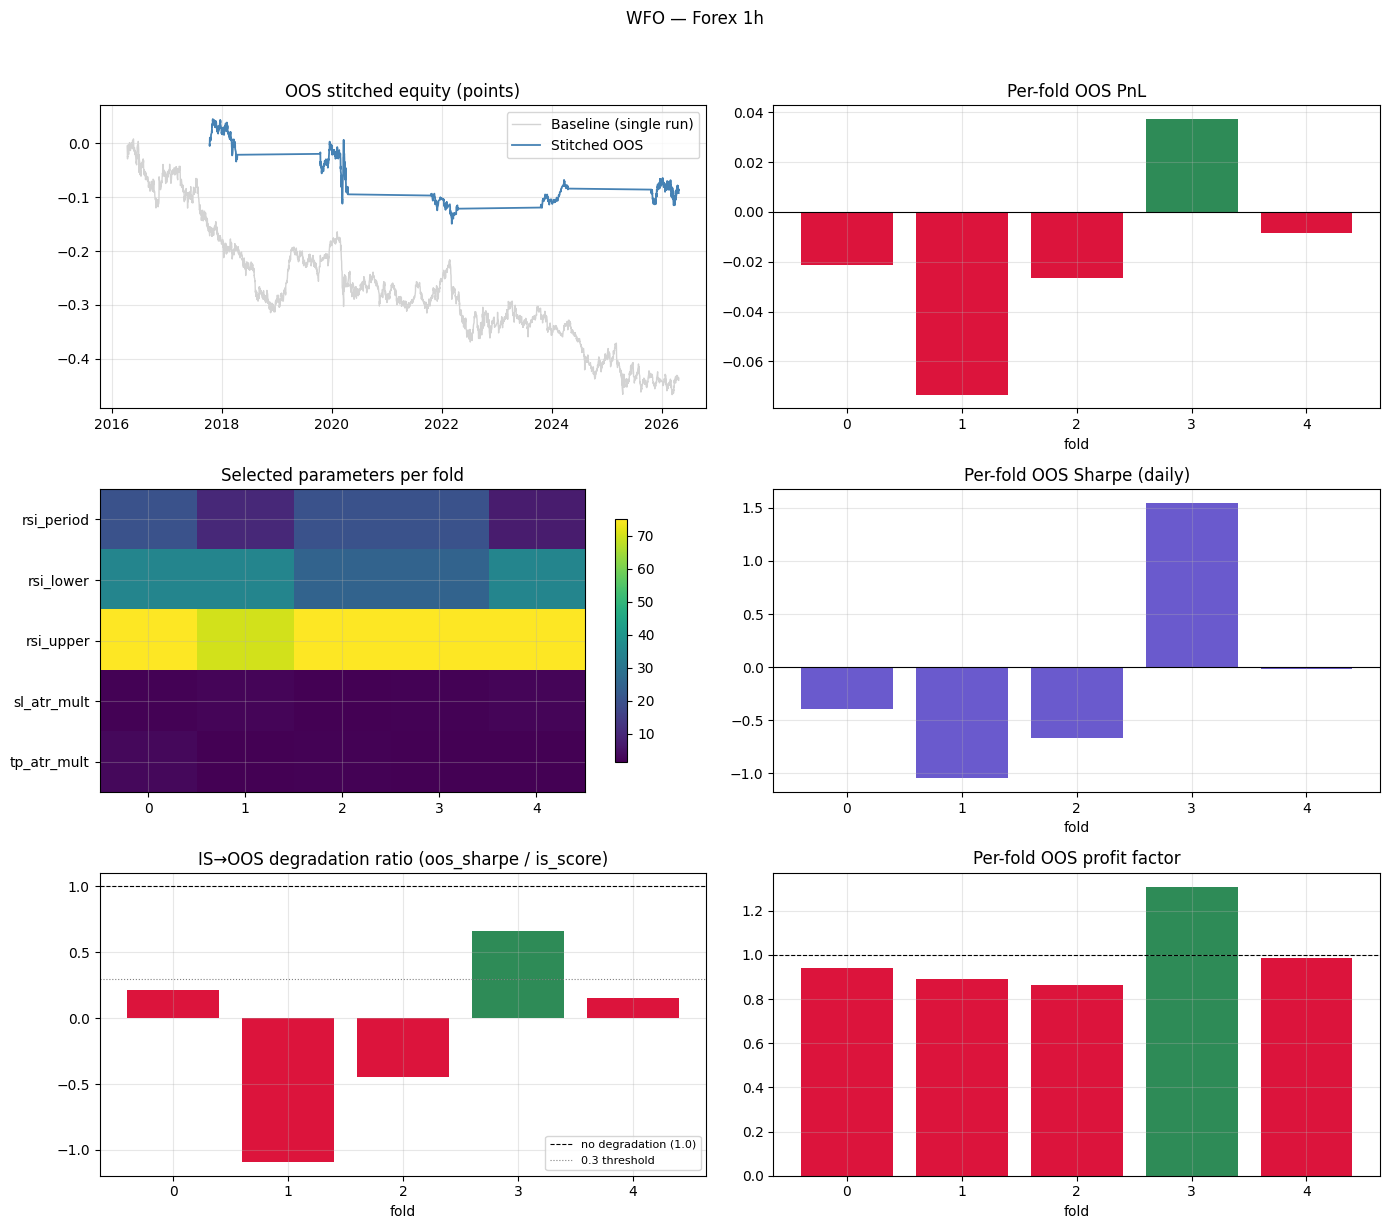

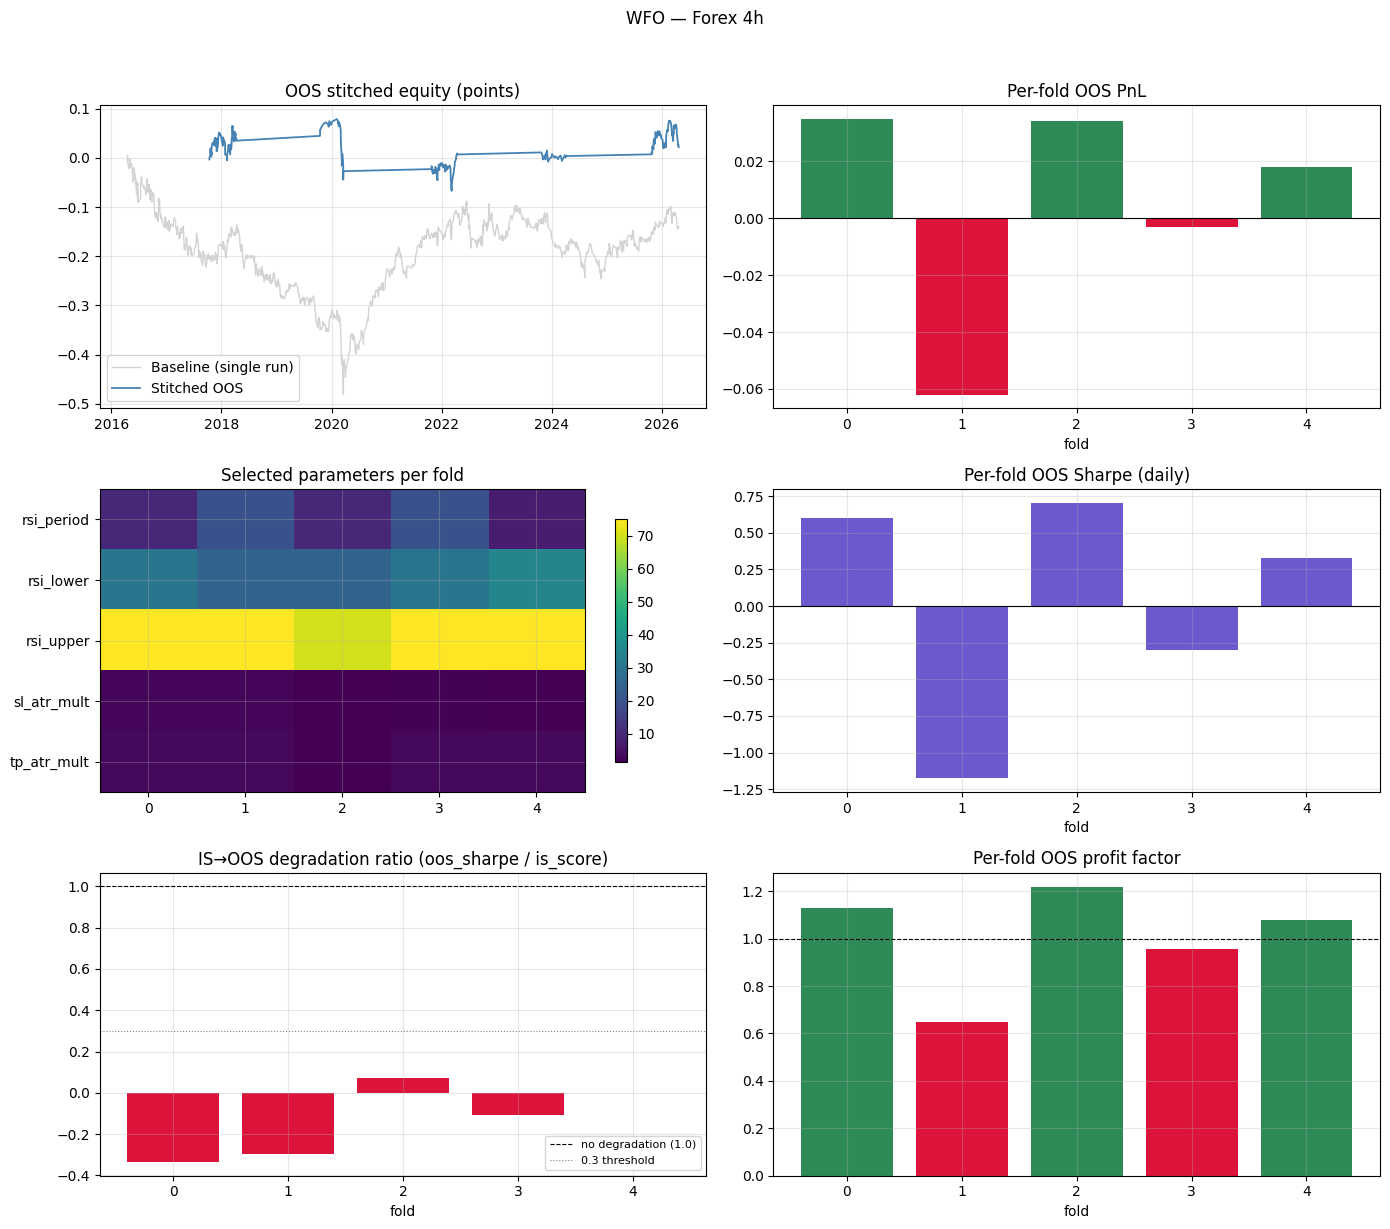

In [9]:
forex_oos_portfolios = {
    tf: _PortfolioResult(wfo.oos_trades, wfo.oos_equity)
    for tf, wfo in wfo_combined["forex"].items()
    if not wfo.oos_trades.empty
}
print("OOS portfolio metrics — Forex (per timeframe):")
display(metrics_comparison(forex_oos_portfolios))

for tf, wfo in wfo_combined["forex"].items():
    if wfo.oos_trades.empty:
        continue
    baseline_eq = baseline_portfolio["forex"][tf].equity
    fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
    fig.suptitle(f"WFO — Forex {tf}", y=1.02)
    plt.show()

### 4.2 WFO-optimized full-history backtest

Pick the **most frequently chosen** parameter combo across the 5 folds per
(group, timeframe, asset), then run a full-history backtest with that combo.
This is the same pattern as the SMA baseline so the two can be compared
side-by-side.

In [10]:
_INT_FIELDS = {"rsi_period", "atr_period", "adx_period"}


def pick_best_params(wfo_windows, fallback):
    """Most common param combo across folds, cast back to RSIMeanReversionParams."""
    if wfo_windows.empty:
        return fallback
    pcols = [c for c in wfo_windows.columns if c.startswith("param_")]
    tuples = [tuple(row[c] for c in pcols) for _, row in wfo_windows.iterrows()]
    best = Counter(tuples).most_common(1)[0][0]
    kw = {c.replace("param_", ""): v for c, v in zip(pcols, best)}
    for k in list(kw):
        if k in _INT_FIELDS:
            kw[k] = int(kw[k])
        else:
            kw[k] = float(kw[k])
    return RSIMeanReversionParams(**kw)


optimized_params = {}
params_by_key = {}
for group, tfs in wfo_per_asset.items():
    optimized_params[group] = {}
    for tf, by_asset in tfs.items():
        optimized_params[group][tf] = {}
        for asset, wfo in by_asset.items():
            p = pick_best_params(wfo.windows, baseline_params)
            optimized_params[group][tf][asset] = p
            params_by_key[(group, tf, asset)] = p

flat_opt = run_backtests_with_params(
    group_tfs,
    params_by_key,
    strategy_cls=RSIMeanReversionStrategy,
    n_jobs=N_JOBS,
    progress=False,
)
opt_per_asset = reshape_grid_results(flat_opt)
optimized_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in opt_per_asset.items()
}

print("Optimized full-history portfolio metrics — Forex:")
display(metrics_comparison(optimized_portfolio["forex"]))

print("\nWFO-picked params per (TF, asset):")
opt_rows = []
for tf, by_asset in optimized_params["forex"].items():
    for asset, params in by_asset.items():
        opt_rows.append({"tf": tf, "asset": asset, **{k: v for k, v in params.as_dict().items() if k in {"rsi_period", "rsi_lower", "rsi_upper", "sl_atr_mult", "tp_atr_mult"}}})
display(pd.DataFrame(opt_rows).set_index(["tf", "asset"]))


Optimized full-history portfolio metrics — Forex:


,15min,1h,4h
num_trades,18519.000000,3453.000000,1427.000000
total_pnl,0.724803,0.106397,0.596461
win_rate,0.571197,0.402549,0.531184
profit_factor,1.047931,1.016908,1.122961
expectancy,0.000039,0.000031,0.000418
max_drawdown,-0.404722,-0.376228,-0.258505
sharpe_daily,0.678479,0.102543,0.473550
sharpe_per_trade,2.619167,0.425466,1.892025
p_value,0.008814,0.670497,0.058488



WFO-picked params per (TF, asset):


rsi_period  rsi_lower  rsi_upper  sl_atr_mult  tp_atr_mult
tf    asset                                                             
15min EURCAD          20       30.0       75.0          2.0          3.0
      EURUSD          20       25.0       65.0          2.0          1.5
      GBPCHF           7       25.0       65.0          2.0          1.5
1h    EURCAD          20       35.0       75.0          2.0          3.0
      EURUSD          20       35.0       65.0          2.0          3.0
      GBPCHF          20       35.0       75.0          1.0          1.5
4h    EURCAD          10       30.0       75.0          2.5          3.0
      EURUSD          10       35.0       70.0          2.5          1.5
      GBPCHF          20       25.0       65.0          1.0          2.0

## 5. Robustness

For each group, the timeframe with the highest OOS daily Sharpe (from §4) is
selected automatically for robustness testing.

1. **Monte Carlo trade-order shuffling** (1,000 runs) — isolates the effect of
   trade *sequence* on the drawdown profile.
2. **Block bootstrap** (1,000 runs) — preserves local trade-streak structure
   while resampling.
3. **Sub-period analysis** (annual) — checks regime sensitivity.
4. **Parameter sensitivity** — one-at-a-time sweeps around the WFO-picked
   params.

In [11]:
def best_oos_tf(group):
    """Timeframe with the highest OOS daily Sharpe for the given group."""
    best_tf_name, best_sharpe = None, -np.inf
    for tf, wfo in wfo_combined[group].items():
        if wfo.oos_trades.empty:
            continue
        eq = wfo.oos_equity
        port = _PortfolioResult(wfo.oos_trades, eq)
        m = compute_metrics(port)
        s = m.get("sharpe_daily", np.nan)
        if not np.isnan(s) and s > best_sharpe:
            best_sharpe = s
            best_tf_name = tf
    return best_tf_name, best_sharpe


best_tfs = {g: best_oos_tf(g)[0] for g in group_tfs}
print("Selected best-OOS timeframes for robustness:", best_tfs)

variations = {
    "rsi_period":  [7, 10, 14, 20],
    "rsi_lower":   [25.0, 30.0, 35.0],
    "rsi_upper":   [65.0, 70.0, 75.0],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5],
    "tp_atr_mult": [1.5, 2.0, 3.0],
}

mc_results = {}
bootstrap_results = {}
subperiod_results = {}
sensitivity_results = {}

for group, tf in best_tfs.items():
    if tf is None:
        print(f"  [skip] {group}: no positive-Sharpe OOS TF")
        continue
    opt_port = optimized_portfolio[group][tf]
    if opt_port.trades.empty:
        print(f"  [skip] {group} {tf}: no optimized trades")
        continue
    print(f"\nRobustness — {group} {tf}  ({len(opt_port.trades)} trades)")

    # Vectorized resampling — one numpy op per call instead of n_runs cumsums.
    mc = monte_carlo_trades(opt_port.trades, n_runs=1000, seed=42)
    mc_results[group] = (mc, monte_carlo_summary(mc))
    print("  monte carlo:", {k: round(v, 4) for k, v in mc_results[group][1].items()})

    bs = block_bootstrap_trades(opt_port.trades, n_runs=1000, seed=42)
    bootstrap_results[group] = (bs, monte_carlo_summary(bs))
    print("  block bootstrap:", {k: round(v, 4) for k, v in bootstrap_results[group][1].items()})

    subperiod_results[group] = subperiod_analysis(opt_port.trades, freq="YE")

    # Parameter sensitivity uses the first asset's optimized params + first
    # asset's df for that (group, tf).  Materialize the DF once, run sensitivity
    # in parallel across (param, value) jobs, then unload.
    asset0 = next(iter(group_tfs[group][tf]))
    base_p = optimized_params[group][tf][asset0]
    with group_tfs[group][tf][asset0].using() as df0:
        sensitivity_results[group] = parameter_sensitivity(
            df0, base_p, variations,
            strategy_cls=RSIMeanReversionStrategy,
            n_jobs=N_JOBS,
        )
    gc.collect()


Selected best-OOS timeframes for robustness: {'forex': '15min'}

Robustness — forex 15min  (18519 trades)


  monte carlo: {'mean_final_pnl': 0.7248, 'median_final_pnl': 0.7248, 'p05_final_pnl': 0.7248, 'p95_final_pnl': 0.7248, 'mean_max_drawdown': -0.1684, 'p95_max_drawdown': -0.2481, 'prob_profitable': 1.0}


  block bootstrap: {'mean_final_pnl': 0.7257, 'median_final_pnl': 0.7314, 'p05_final_pnl': 0.2516, 'p95_final_pnl': 1.1995, 'mean_max_drawdown': -0.1861, 'p95_max_drawdown': -0.3011, 'prob_profitable': 0.993}


In [12]:
for group, sub_df in subperiod_results.items():
    if sub_df.empty:
        continue
    print(f"\nSub-period (yearly) metrics — {group} {best_tfs[group]}:")
    display(sub_df[["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "win_rate"]].round(3))


Sub-period (yearly) metrics — forex 15min:


,num_trades,total_pnl,sharpe_daily,profit_factor,win_rate
period,,,,,
2016,1289,0.318,2.562,1.224,0.591
2017,1775,-0.018,-0.161,0.989,0.559
2018,1802,-0.060,-0.555,0.964,0.550
2019,1823,-0.009,-0.039,0.994,0.564
2020,1812,-0.125,-1.093,0.932,0.539
2021,1862,-0.039,-0.433,0.972,0.551
2022,1896,0.172,1.490,1.097,0.593
2023,1878,0.247,2.930,1.208,0.606
2024,1914,0.089,1.147,1.077,0.571


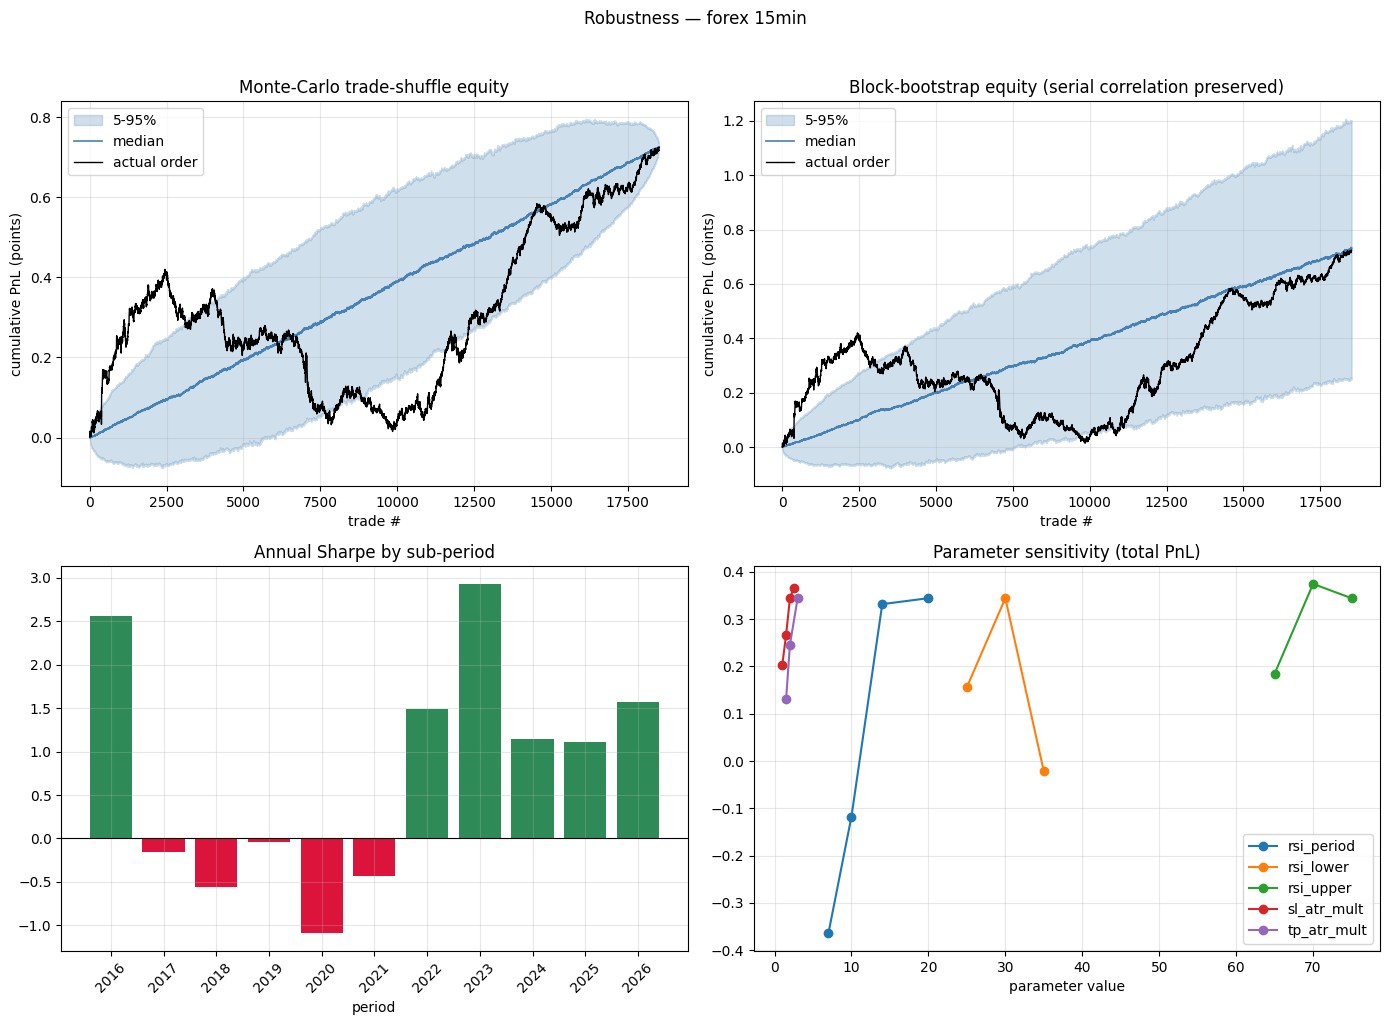

In [13]:
for group, tf in best_tfs.items():
    if tf is None or group not in mc_results or group not in sensitivity_results:
        continue
    opt_trades = optimized_portfolio[group][tf].trades
    if opt_trades.empty:
        continue
    mc_df, _ = mc_results[group]
    bs_df, _ = bootstrap_results[group]
    sens_df = sensitivity_results[group]
    sub_df = subperiod_results.get(group, pd.DataFrame())

    fig = plot_robustness_dashboard(
        mc_df=mc_df,
        baseline_equity=optimized_portfolio[group][tf].equity,
        sensitivity=sens_df,
        block_bootstrap_df=bs_df,
        subperiod_df=sub_df,
    )
    fig.suptitle(f"Robustness — {group} {tf}", y=1.02)
    plt.show()

## 6. Takeaways

This notebook establishes a baseline RSI mean-reversion result on the Forex
group with the parameter ranges and entry / exit rules specified in
[`02_RSI_Mean_Reversion.md`](../DocumentationVault/strategies/02_RSI_Mean_Reversion.md).

What it gives us:

- A reproducible end-to-end pipeline (load → multi-TF → baseline → WFO →
  robustness) for the strategy, sharing the same `Backtester`, `walk_forward`,
  and robustness helpers as the SMA crossover baseline.
- A comparable structure for cross-strategy analysis: the §3 baseline metrics
  and §4 OOS metrics tables can be diffed directly against
  `01_baseline_sma_crossover.ipynb`.

Open items (not addressed here):

- **Midline exit (RSI = 50 cross)** — described in the doc but disabled in this
  notebook because the existing `Backtester` doesn't yet support custom signal
  exits beyond reversal / SL / TP / session-end. Adding a "neutralize" signal
  path is a separate change.
- **ADX regime filter** — `use_adx_filter=False` here. Toggling it on (and
  including `adx_max` in the WFO grid) is a natural follow-up.
- **Crypto coverage** — the doc lists BTCUSDT / ETHUSDT but neither dataset is
  in `data/crypto/`. Adding crypto data and re-running this notebook would
  validate whether the edge generalizes.
- **§7 extensions** — session filter, sizing modes, correlation-aware
  weighting. These are out of scope here and will be added in a follow-up
  notebook revision.